# Análisis univariado - Base de Leads

Mismo patrón de `4_Extracción_de_Características.ipynb` (tabla de frecuencias → filtro → índice → gráfico de barras) aplicado a `Origen`, `Título`, `Nombre` y `Comentario` de la Base de Leads ya limpia.

## Preparación

In [4]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#Carga desde el archivo .csv ya limpio (ajusta la ruta si no esta en la misma carpeta que este notebook)
Base_Leads = pd.read_csv('Base_de_Leads_Limpia.csv', encoding='utf-8-sig')

## Análisis univariado: Origen

Aviso antes de correrlo: en este archivo `Origen` tiene un solo valor (`PLAZA ANGELOPOLIS`) en las 210 filas — no varía. El gráfico va a mostrar una sola barra; lo dejo con la misma estructura de todas formas para que quede listo en caso de que uses esto con una base que combine más de una plaza/origen.

In [6]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = Base_Leads['Origen'].value_counts().reset_index()
Tabla_freq

,Origen,count
0,PLAZA ANGELOPOLIS,210


In [7]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>1]
Filtro

,Origen,count
0,PLAZA ANGELOPOLIS,210


In [8]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('Origen')
Filtro_index

,count
Origen,
PLAZA ANGELOPOLIS,210


Text(0, 0.5, 'Frecuencia')

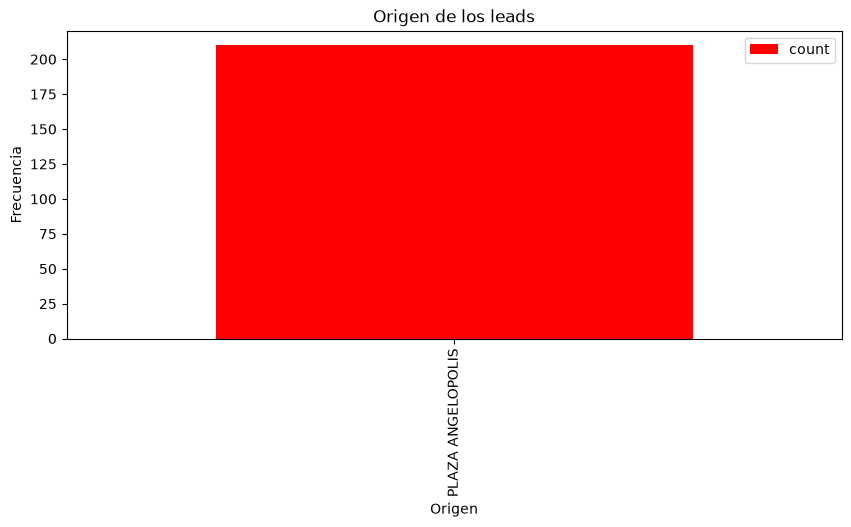

In [9]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "red")
plt.title('Origen de los leads')
plt.xlabel('Origen')
plt.ylabel('Frecuencia')

## Análisis univariado: Título

In [10]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = Base_Leads['Titulo'].value_counts().reset_index()
Tabla_freq

,Titulo,count
0,Lead ANGE,196
1,Lead ANGE - Return,14


In [11]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>1]
Filtro

,Titulo,count
0,Lead ANGE,196
1,Lead ANGE - Return,14


In [12]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('Titulo')
Filtro_index

,count
Titulo,
Lead ANGE,196
Lead ANGE - Return,14


Text(0, 0.5, 'Frecuencia')

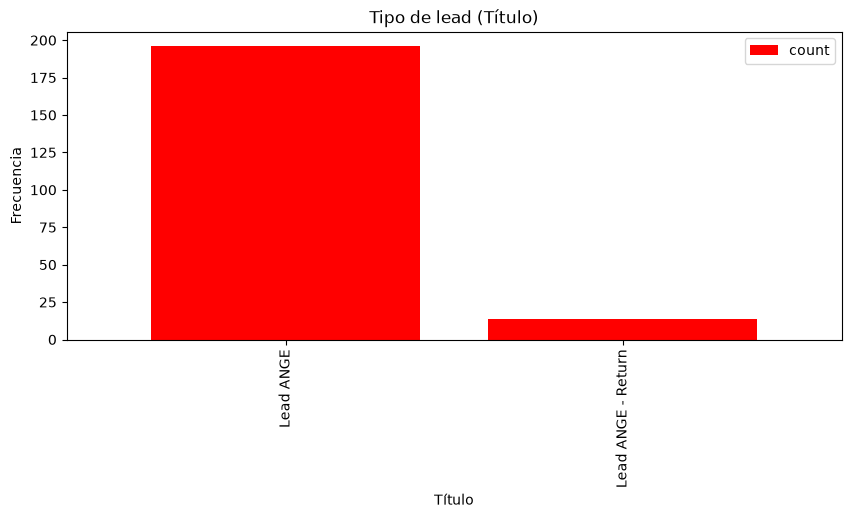

In [13]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "red")
plt.title('Tipo de lead (Título)')
plt.xlabel('Título')
plt.ylabel('Frecuencia')

## Análisis univariado: Nombre

`Nombre` casi no tiene repetidos (cada lead es, en general, un cliente distinto), así que con el filtro `count>1` el gráfico muestra únicamente a los clientes que aparecen más de una vez — en los datos limpios son 3: seguramente volvieron a dejar sus datos en otro momento.

In [14]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = Base_Leads['Nombre'].value_counts().reset_index()
Tabla_freq.head()

,Nombre,count
0,Omar Tovar,2
1,Alvaro Delgadillo,2
2,Raul Sanchez,2
3,Apolonio Torres Perez,1
4,Javier Nieto,1


In [15]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>1]
Filtro

,Nombre,count
0,Omar Tovar,2
1,Alvaro Delgadillo,2
2,Raul Sanchez,2


In [16]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('Nombre')
Filtro_index

,count
Nombre,
Omar Tovar,2
Alvaro Delgadillo,2
Raul Sanchez,2


Text(0, 0.5, 'Frecuencia')

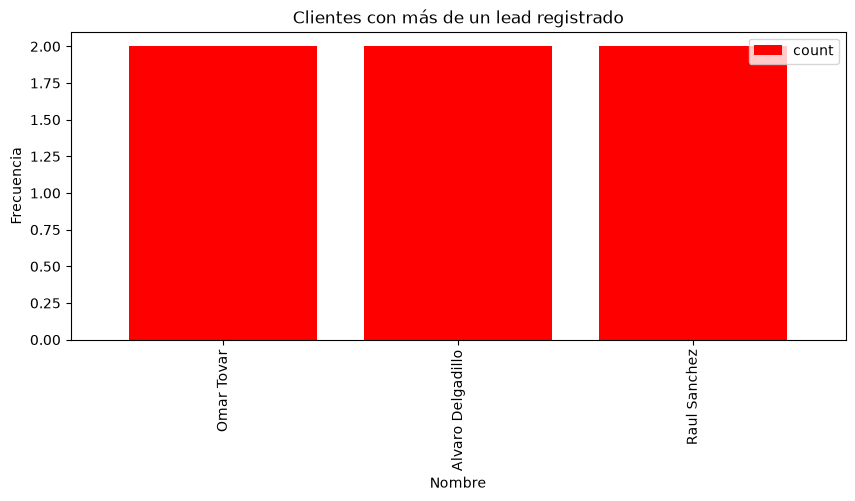

In [17]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "red")
plt.title('Clientes con más de un lead registrado')
plt.xlabel('Nombre')
plt.ylabel('Frecuencia')

## Análisis univariado: Comentario (interés de los clientes)

`Comentario` es texto libre — casi 200 redacciones distintas, así que graficarlo tal cual no serviría de nada (nada se repite). Pero 196 de los 210 comentarios sí traen una etiqueta reconocible al final, `Pidieron:PRODUCTO` o `Final:PRODUCTO`, que indica el producto que le interesó al cliente o con el que se cerró el lead. Esa es la perspectiva de interés del cliente que se puede extraer de forma confiable — así que la usamos como la categoría a analizar, en vez del texto completo. A los 14 comentarios que no traen esa etiqueta (más 3 donde la etiqueta viene vacía) se les asigna "Sin producto especificado".

In [18]:
import re

#Extraemos el producto que el cliente pidió o con el que se finalizó el lead, desde el texto de Comentario
interes = Base_Leads['Comentario'].str.extract(r'(?:Pidieron|Final):\s*(.*)$', flags=re.IGNORECASE)[0]
interes = interes.str.strip().replace('', pd.NA).fillna('Sin producto especificado')

Base_Leads['Interes_Comentario'] = interes
Base_Leads['Interes_Comentario'].head()

0         EMZOOM
1     GS4 MAX GL
2    GS4 MAX HEV
3      EMKOO HEV
4      EMKOO HEV
Name: Interes_Comentario, dtype: str

In [19]:
#Obtengo un análisis univariado de las variables categóricas
Tabla_freq = Base_Leads['Interes_Comentario'].value_counts().reset_index()
Tabla_freq

,Interes_Comentario,count
0,EMZOOM,89
1,EMKOO,44
2,EMKOO HEV,32
3,GS4 MAX HEV,18
4,Sin producto especificado,17
5,GS8,4
6,GS8 HEV,3
7,GS4 MAX GL,1
8,GN8,1
9,AION Y,1


In [20]:
#Obtengo un filtro de los valores más reelevantes de la variable categórica seleccionada
Filtro= Tabla_freq[Tabla_freq['count']>1]
Filtro

,Interes_Comentario,count
0,EMZOOM,89
1,EMKOO,44
2,EMKOO HEV,32
3,GS4 MAX HEV,18
4,Sin producto especificado,17
5,GS8,4
6,GS8 HEV,3


In [21]:
#Ajusto el indice de mi dataframe
Filtro_index= Filtro.set_index('Interes_Comentario')
Filtro_index

,count
Interes_Comentario,
EMZOOM,89
EMKOO,44
EMKOO HEV,32
GS4 MAX HEV,18
Sin producto especificado,17
GS8,4
GS8 HEV,3


Text(0, 0.5, 'Frecuencia')

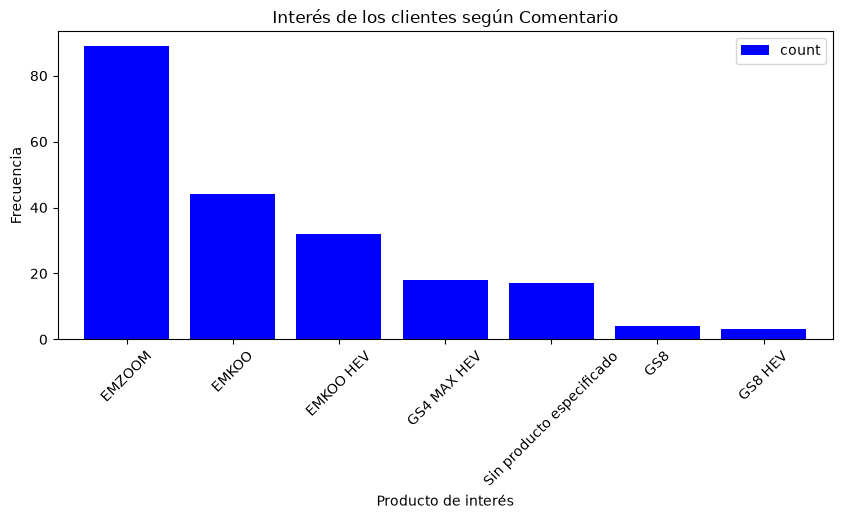

In [23]:
#Realizamos grafico de barras del dataframe filtrado
Filtro_index.plot(kind = 'bar', width=0.8, figsize=(10,4), color= "blue", rot=45)
plt.title('Interés de los clientes según Comentario')
plt.xlabel('Producto de interés')
plt.ylabel('Frecuencia')